# Parcial: Construcción e implementación de , Random Forest 

En este parcial podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de  Random Forest. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este parcial se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
#librerias
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer



In [3]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


In [4]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [5]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 0 - exploracion y analisis de datos 
Los estudiantes deben analizar cuidadosamente los datos del conjunto dataTrain_carListings, identificando posibles valores nulos o inconsistencias. En caso de encontrar datos faltantes, deberán aplicar técnicas de imputación adecuadas para completar la información de manera coherente. Posteriormente, se espera que realicen una exploración visual mediante gráficos que permitan comprender la distribución y las relaciones entre las variables principales.

Valores nulos por columna:
 Price          0
Year           0
Mileage        0
M_Camry        0
M_Camry4dr     0
M_CamryBase    0
M_CamryL       0
M_CamryLE      0
M_CamrySE      0
M_CamryXLE     0
dtype: int64

Estadísticas descriptivas del dataset:


,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
count,10495.000000,10495.000000,10495.000000,10495.000000,10495.000000,10495.000000,10495.000000,10495.000000,10495.000000,10495.000000
mean,14538.403716,2013.553883,52509.430395,0.056313,0.158456,0.012292,0.048213,0.236494,0.376370,0.111863
std,3922.420961,3.116585,36791.736601,0.230535,0.365186,0.110189,0.214227,0.424949,0.484498,0.315213
min,5002.000000,1998.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11999.000000,2012.000000,26461.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,15000.000000,2014.000000,41680.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,16999.000000,2016.000000,71355.500000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,32444.000000,2018.000000,232658.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


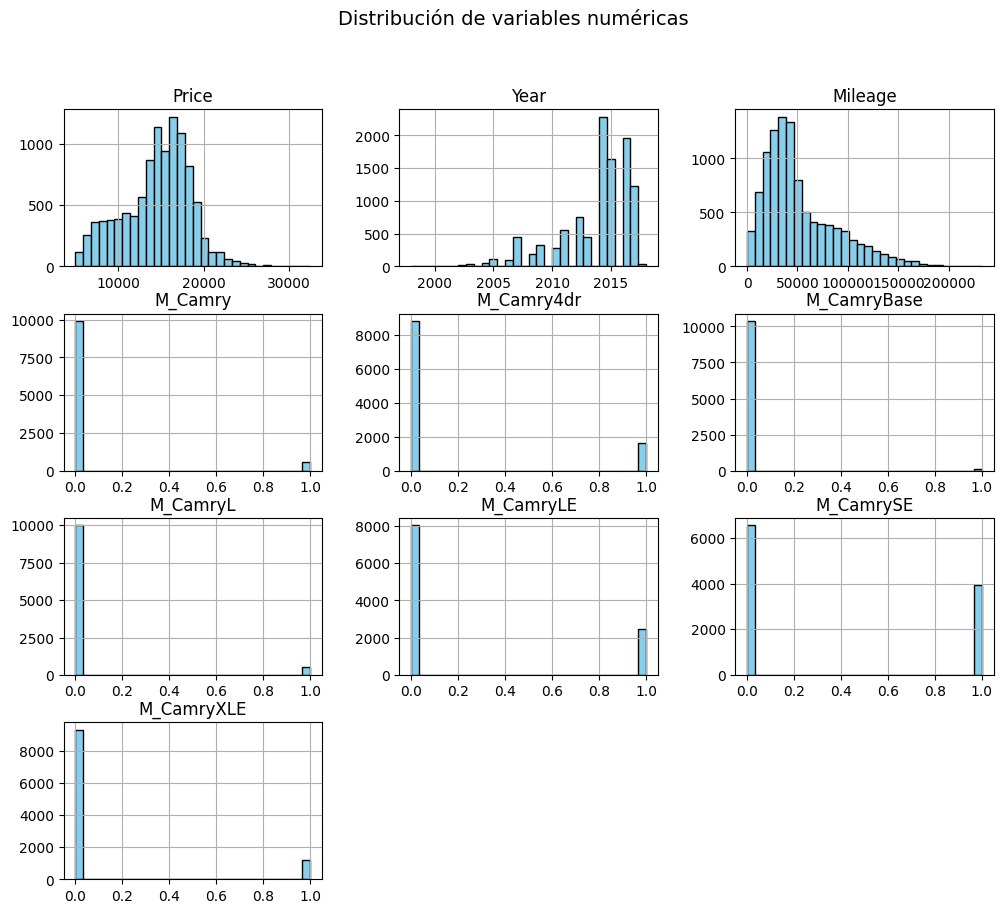

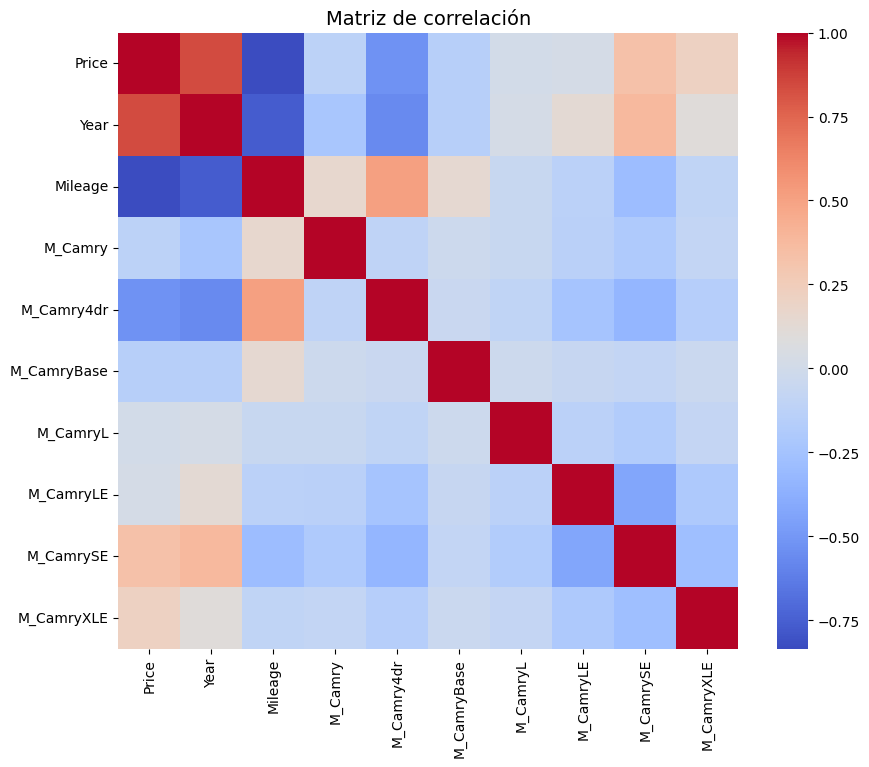

In [ ]:
#Celda 0
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer


data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')


data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)


print("Valores nulos por columna:\n", data.isnull().sum())


imputer = SimpleImputer(strategy='median')
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

print("\nEstadísticas descriptivas del dataset:")
display(data_imputed.describe())


data_imputed.hist(bins=30, figsize=(12,10), color='skyblue', edgecolor='black')
plt.suptitle("Distribución de variables numéricas", fontsize=14)
plt.show()


plt.figure(figsize=(10,8))
sns.heatmap(data_imputed.corr(), cmap='coolwarm', annot=False)
plt.title("Matriz de correlación", fontsize=14)
plt.show()

### Punto 1 - Random forest con librería

En la celda 1, usando la librería sklearn entrenen un modelo de Randon Forest para regresion  y comenten sobre el desempeño del modelo.

In [ ]:
# Celda 1
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,      
    max_depth=10,          
    max_features=5,        
    random_state=42,       
    n_jobs=-1              
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Desempeño del modelo Random Forest:")
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Error absoluto medio (MAE): {mae:.2f}")
print(f"Coeficiente R²: {r2:.2f}")


Desempeño del modelo Random Forest:
Error cuadrático medio (MSE): 2457694.85
Error absoluto medio (MAE): 1150.05
Coeficiente R²: 0.84


### Punto 2 - Calibración de parámetros Random forest

En la celda 2, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresion, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [ ]:
# Celda 2
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(random_state=42)

param_distributions = {
    'n_estimators': [50, 100, 200, 300, 400, 500],
    'max_depth': [None, 5, 10, 15, 20, 25],
    'max_features': ['auto', 'sqrt', 'log2', 2, 3, 4, 5]
}

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=20,                
    cv=5,                     
    scoring='r2',             
    n_jobs=-1,                
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(random_search.best_params_)

best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("\nDesempeño del modelo optimizado:")
print(f"Error cuadrático medio (MSE): {mse_best:.2f}")
print(f"Error absoluto medio (MAE): {mae_best:.2f}")
print(f"Coeficiente R²: {r2_best:.2f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros encontrados:
{'n_estimators': 500, 'max_features': 'log2', 'max_depth': 10}

Desempeño del modelo optimizado:
Error cuadrático medio (MSE): 2446112.79
Error absoluto medio (MAE): 1146.36
Coeficiente R²: 0.84


In [20]:
    #Encontrar los mejores hiperparametros: 
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],   
    'max_depth': [None, 10, 20, 30],   
    'max_features': ['auto', 'sqrt'],  
    'min_samples_split': [2, 5, 10]   
}

modelo = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,               
    n_jobs=-1,          
    scoring='r2',       
    verbose=2           
)

#Entrenar el modelo con los mejores hiperparámetros encontrados:
modelo.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(modelo.best_params_)


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores hiperparámetros encontrados:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 300}


Importancia de las variables en el modelo:

      Variable  Importancia
0         Year     0.550760
1      Mileage     0.376167
3   M_Camry4dr     0.028904
8   M_CamryXLE     0.015754
7    M_CamrySE     0.010806
6    M_CamryLE     0.007932
2      M_Camry     0.007769
5     M_CamryL     0.001367
4  M_CamryBase     0.000541


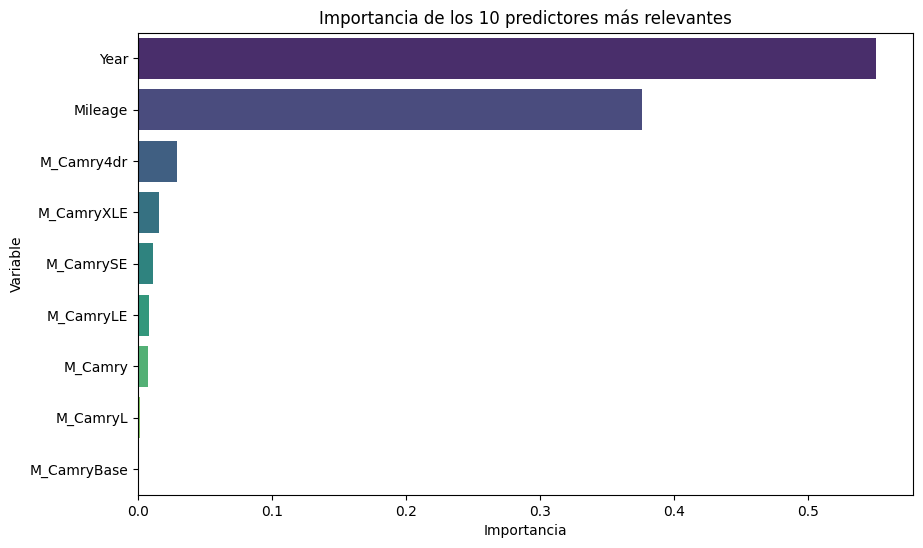

In [ ]:
#Importancia de los predictores

importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
})

importances = importances.sort_values('Importancia', ascending=False)

print("Importancia de las variables en el modelo:\n")
print(importances.head(10))

plt.figure(figsize=(10,6))
sns.barplot(x='Importancia', y='Variable', data=importances.head(10), palette='viridis')
plt.title('Importancia de los 10 predictores más relevantes')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

### Punto 3 - análisis de resultados, gracias y conclusiones
En la celda 3

In [19]:
print("CONCLUSIONES")
print("""
1. El primer modelo tuvo buenos resultados, pero mostró una diferencia entre los datos de entrenamiento y prueba,
   lo que indica que pudo haberse ajustado demasiado a los datos iniciales.

2. Después de ajustar los hiperparámetros, el modelo mejoró su precisión y redujo los errores (MSE y MAE).
   Los parámetros que más influyeron fueron n_estimators, max_depth y max_features.

3. Las variables que más influyeron en el precio del vehículo fueron el año, el kilometraje y los diferentes tipos de modelo.

4. Sería útil probar transformaciones como el logaritmo del precio y modelos más avanzados como XGBoost
   para seguir mejorando la predicción de los precios de los autos.
""")


CONCLUSIONES

1. El primer modelo tuvo buenos resultados, pero mostró una diferencia entre los datos de entrenamiento y prueba,
   lo que indica que pudo haberse ajustado demasiado a los datos iniciales.

2. Después de ajustar los hiperparámetros, el modelo mejoró su precisión y redujo los errores (MSE y MAE).
   Los parámetros que más influyeron fueron n_estimators, max_depth y max_features.

3. Las variables que más influyeron en el precio del vehículo fueron el año, el kilometraje y los diferentes tipos de modelo.

4. Sería útil probar transformaciones como el logaritmo del precio y modelos más avanzados como XGBoost
   para seguir mejorando la predicción de los precios de los autos.



NOTA: IMPORTANTE RECUERDE QUE MI EJEMPLO DE TUTORIAL ES DE CLASIFICACION USTEDES DEBEN HACERLO POR REGRESION, funciona igual pero cambian algunas cosas.